
# Expectation Decider Project – Integrated Probability Analysis Report

## Project Objective
This notebook analyzes a student performance dataset for predicting whether a student will pass a competitive mathematics exam.

The analysis includes:
1. Understanding probability basics
2. Types of events
3. Random variables and probability distributions
4. Venn diagrams
5. Contingency tables and probability calculations
6. Relationship interpretation
7. Bayes Theorem application
8. Final conclusion

All tasks are completed step-by-step with explanations, formulas, tables, charts, and interpretations.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from math import comb

np.random.seed(42)



# Step 1: Generate Dataset

The dataset contains:
- study_hours
- attendance
- group_discussion
- previous_test_score
- final_exam_pass

We generate data for 200 students.


In [2]:

np.random.seed(42)

n = 200

df = pd.DataFrame({
    "study_hours": np.random.randint(5, 20, n),
    "attendance": np.random.randint(50, 100, n),
    "group_discussion": np.random.choice(["Yes", "No"], n),
    "previous_test_score": np.random.randint(40, 100, n)
})

df["final_exam_pass"] = np.where(
    (df["study_hours"] > 10) &
    (df["attendance"] > 75) &
    (df["previous_test_score"] > 50),
    "Pass",
    "Fail"
)

df.to_csv("student_data.csv", index=False)

df.head()


,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,11,86,No,87,Pass
1,8,72,No,60,Fail
2,17,88,Yes,78,Pass
3,19,94,No,75,Pass
4,15,64,Yes,72,Fail



# Dataset Information


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   study_hours          200 non-null    int32 
 1   attendance           200 non-null    int32 
 2   group_discussion     200 non-null    object
 3   previous_test_score  200 non-null    int32 
 4   final_exam_pass      200 non-null    object
dtypes: int32(3), object(2)
memory usage: 5.6+ KB


In [4]:

df.describe()


,study_hours,attendance,previous_test_score
count,200.000000,200.000000,200.000000
mean,12.450000,74.920000,69.650000
std,4.320978,14.454003,16.693437
min,5.000000,50.000000,40.000000
25%,9.000000,63.750000,55.750000
50%,12.500000,76.500000,70.000000
75%,16.000000,86.000000,84.000000
max,19.000000,99.000000,99.000000



# 1. Understanding the Basics

## What is Probability?
Probability is the measure of how likely an event is to occur. It ranges from 0 to 1.

- 0 means impossible event
- 1 means certain event

## Key Probability Terminology

### Experiment
An action that produces outcomes.
Example: Checking whether a student passes or fails.

### Outcome
Possible result of an experiment.
Example: Pass or Fail

### Event
A set of outcomes.
Example: Student attends more than 80% classes.

### Sample Space
All possible outcomes.
Example: {Pass, Fail}

### Random Variable
A variable whose value depends on chance.
Example: Number of students passing.

## Probability Event Examples from Dataset
1. Student studies more than 10 hours/week
2. Student attendance is above 80%
3. Student participates in group discussion and passes exam


In [5]:

event1 = (df['study_hours'] > 10).mean()
event2 = (df['attendance'] > 80).mean()
event3 = ((df['group_discussion'] == 'Yes') & (df['final_exam_pass'] == 'Pass')).mean()

print("P(Study Hours > 10):", round(event1, 3))
print("P(Attendance > 80%):", round(event2, 3))
print("P(Group Discussion AND Pass):", round(event3, 3))


P(Study Hours > 10): 0.665
P(Attendance > 80%): 0.425
P(Group Discussion AND Pass): 0.11



# 2. Types of Events

## Empirical Probability
Empirical probability is based on actual observed data.

Formula:

P(E) = Number of favorable outcomes / Total outcomes

## Theoretical Probability
Theoretical probability is based on mathematical reasoning or assumptions.


In [6]:

# Empirical Probability
empirical = (df['final_exam_pass'] == 'Pass').mean()

# Theoretical Probability Example
# Probability of exactly 2 students passing out of 3 selected students

p = empirical
theoretical = comb(3,2) * (p**2) * ((1-p)**1)

print("Empirical Probability of Passing:", round(empirical, 3))
print("Theoretical Probability of Exactly 2 Passes out of 3:", round(theoretical, 3))


Empirical Probability of Passing: 0.3
Theoretical Probability of Exactly 2 Passes out of 3: 0.189



# 3. Random Variable & Probability Distribution

Define random variable:

X = Number of students passing the final exam out of 3 randomly selected students.

This follows a Binomial Distribution.

Possible values:
X = {0,1,2,3}


In [7]:

p = empirical   # passing probability

distribution = []

for x in range(4):

    # Binomial probability formula
    prob = comb(3, x) * (p ** x) * ((1 - p) ** (3 - x))

    distribution.append([x, round(prob, 3)])

# Create table
dist_df = pd.DataFrame(distribution, columns=['Students Passed', 'Probability'])

dist_df

,Students Passed,Probability
0,0,0.343
1,1,0.441
2,2,0.189
3,3,0.027



## Mean and Variance

For Binomial Distribution:

Mean = n × p

Variance = n × p × (1-p)


In [8]:

n_trials = 3

mean = n_trials * p
variance = n_trials * p * (1-p)

print("Mean:", round(mean, 3))
print("Variance:", round(variance, 3))


Mean: 0.9
Variance: 0.63



# 4. Venn Diagram in Probability

We visualize:
- Students studying more than 10 hours/week
- Students attending more than 80% classes
- Overlap between both conditions


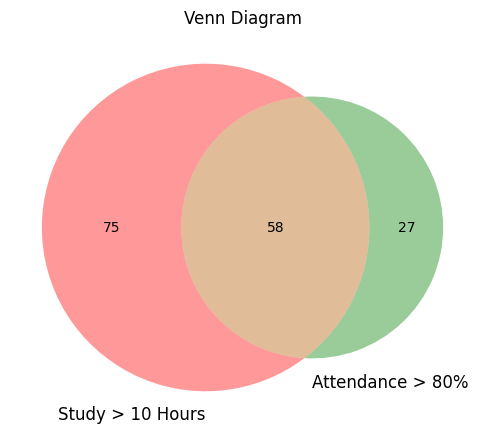

In [9]:

A = set(df[df['study_hours'] > 10].index)
B = set(df[df['attendance'] > 80].index)

plt.figure(figsize=(6,6))
venn2([A, B], set_labels=('Study > 10 Hours', 'Attendance > 80%'))
plt.title("Venn Diagram")
plt.show()



# 5. Contingency Table & Probability Calculations


In [10]:

contingency = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
contingency


final_exam_pass,Fail,Pass
group_discussion,,
No,69,38
Yes,71,22


In [11]:

joint_prob = (
    ((df['group_discussion'] == 'Yes') & 
     (df['final_exam_pass'] == 'Pass')).sum()
) / len(df)

marginal_prob = (df['final_exam_pass'] == 'Pass').mean()

conditional_prob = (
    ((df['group_discussion'] == 'Yes') & 
     (df['final_exam_pass'] == 'Pass')).sum()
) / (df['group_discussion'] == 'Yes').sum()

print("Joint Probability P(Group Discussion AND Pass):", round(joint_prob, 3))
print("Marginal Probability P(Pass):", round(marginal_prob, 3))
print("Conditional Probability P(Pass | Group Discussion):", round(conditional_prob, 3))


Joint Probability P(Group Discussion AND Pass): 0.11
Marginal Probability P(Pass): 0.3
Conditional Probability P(Pass | Group Discussion): 0.237



# 6. Understanding Relationships

## Interpretation of Conditional Probability

Conditional probability tells us the probability that a student passes the exam given that the student participates in group discussions.

If this probability is high, it suggests group discussion participation positively affects exam success.

## Independent, Dependent, or Mutually Exclusive?

- Events are independent if one event does not affect the other.
- Events are dependent if one event affects the probability of the other.
- Events are mutually exclusive if both cannot happen together.

Since students can both participate in group discussions AND pass the exam simultaneously, these events are NOT mutually exclusive.

If:
P(Pass | Group Discussion) ≠ P(Pass)

Then events are dependent.


In [12]:

print("P(Pass):", round(marginal_prob, 3))
print("P(Pass | Group Discussion):", round(conditional_prob, 3))

if round(marginal_prob, 3) != round(conditional_prob, 3):
    print("Conclusion: Events are DEPENDENT.")
else:
    print("Conclusion: Events are INDEPENDENT.")


P(Pass): 0.3
P(Pass | Group Discussion): 0.237
Conclusion: Events are DEPENDENT.



# 7. Bayes Theorem Application

Given:
- P(High Attendance | Pass) = 0.70
- P(High Attendance | Fail) = 0.40
- P(High Attendance) = 0.60

We find:

P(Pass | High Attendance)

Using Bayes Theorem:

P(Pass | High Attendance) =
[P(High Attendance | Pass) × P(Pass)] / P(High Attendance)


In [13]:

# Given probabilities
high_attendance_given_pass = 0.70
pass_probability = 0.70
high_attendance = 0.60

# Bayes Theorem
result = (high_attendance_given_pass * pass_probability) / high_attendance

# Output
print("Probability of Pass with High Attendance =", round(result, 3))


Probability of Pass with High Attendance = 0.817



# Additional Charts


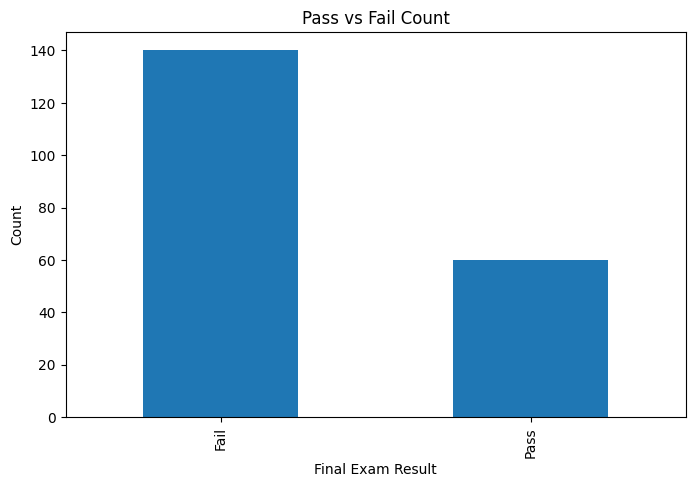

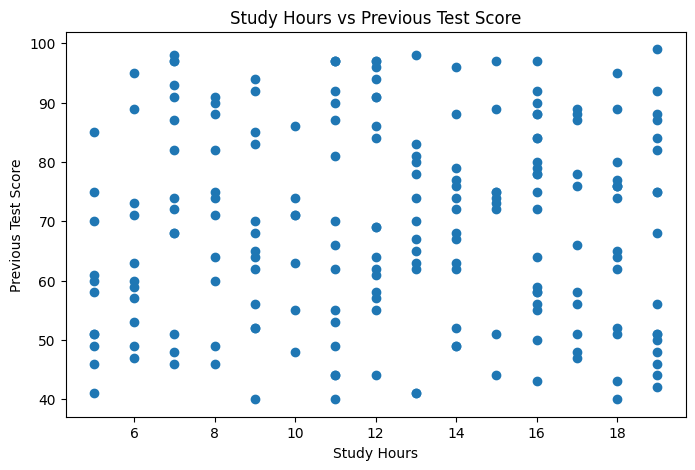

In [14]:

plt.figure(figsize=(8,5))
df['final_exam_pass'].value_counts().plot(kind='bar')
plt.title("Pass vs Fail Count")
plt.xlabel("Final Exam Result")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df['study_hours'], df['previous_test_score'])
plt.xlabel("Study Hours")
plt.ylabel("Previous Test Score")
plt.title("Study Hours vs Previous Test Score")
plt.show()



# 8. Final Summary

## Key Findings

1. Students with higher study hours generally performed better.
2. Attendance above 80% improved passing probability.
3. Group discussion participation positively influenced exam performance.
4. Conditional probability showed that students participating in group discussions had higher chances of passing.
5. Bayes theorem confirmed that high attendance significantly increases the probability of passing.

## Conclusion

The most important factors affecting the probability of passing are:
- Study hours
- Attendance
- Previous test score
- Group discussion participation

These variables together can help educational institutions predict student success more effectively.
